Random Forest Tree

In [1]:
from collections import Counter
import ast
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
def count_items(value):
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if text in ('', '[]', 'nan', 'None'):
        return 0

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set, dict)):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass

    cleaned = text.strip('[]')
    if not cleaned:
        return 0

    return len([item for item in cleaned.split(',') if item.strip()])

def word_count(value):
    if pd.isna(value):
        return 0
    text = str(value).strip()
    if text in ('', 'nan', 'None'):
        return 0
    return len([word for word in text.split() if word.strip()])

venue_counter = Counter()
for chunk in pd.read_csv('dblp-v10.csv', usecols=['venue'], chunksize=50000):
    venues = chunk['venue'].dropna().astype(str).str.strip()
    venues = venues[venues.ne('')]
    venue_counter.update(venues)

top_venues = [venue for venue, _ in venue_counter.most_common(3)]
top_venues

['international conference on acoustics, speech, and signal processing',
 'international conference on robotics and automation',
 'Lecture Notes in Computer Science']

In [3]:
df = pd.read_csv('dblp-v10.csv', nrows=5)
df

,abstract,authors,n_citation,references,title,venue,year,id
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e


In [4]:
chunks = []
for chunk in pd.read_csv('dblp-v10.csv', usecols=['abstract', 'authors', 'n_citation', 'references', 'title', 'venue', 'year', 'id'], chunksize=50000, engine='python'):
    chunk = chunk.drop_duplicates().copy()
    text_columns = ['abstract', 'authors', 'references', 'title', 'venue', 'id']
    chunk[text_columns] = chunk[text_columns].fillna('')
    chunk['year'] = pd.to_numeric(chunk['year'], errors='coerce')
    chunk['n_citation'] = pd.to_numeric(chunk['n_citation'], errors='coerce')
    chunk = chunk.dropna(subset=['year', 'n_citation']).copy()
    chunk['year'] = chunk['year'].astype(int)
    chunk = chunk[chunk['venue'].isin(top_venues)].copy()
    chunk['reference_count'] = chunk['references'].apply(count_items)
    chunk['author_count'] = chunk['authors'].apply(count_items)
    chunk['title_char_count'] = chunk['title'].str.len()
    chunk['abstract_char_count'] = chunk['abstract'].str.len()
    chunk['id_length'] = chunk['id'].str.len()
    chunk['title_word_count'] = chunk['title'].apply(word_count)
    chunk['abstract_word_count'] = chunk['abstract'].apply(word_count)
    chunk['title_has_digits'] = chunk['title'].str.contains(r'\d', regex=True).astype(int)
    chunk['abstract_has_digits'] = chunk['abstract'].str.contains(r'\d', regex=True).astype(int)
    chunk['id_hyphen_count'] = chunk['id'].str.count('-')
    chunk['venue_char_count'] = chunk['venue'].str.len()
    chunk['venue_word_count'] = chunk['venue'].apply(word_count)
    if not chunk.empty:
        chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True).drop_duplicates().copy()
print('Cleaned rows:', len(df))
print('Duplicate rows:', df.duplicated().sum())
print('Missing values per column:')
print(df.isna().sum())
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
df.head()

Cleaned rows: 29863
Duplicate rows: 0
Missing values per column:
abstract               0
authors                0
n_citation             0
references             0
title                  0
venue                  0
year                   0
id                     0
reference_count        0
author_count           0
title_char_count       0
abstract_char_count    0
id_length              0
title_word_count       0
abstract_word_count    0
title_has_digits       0
abstract_has_digits    0
id_hyphen_count        0
venue_char_count       0
venue_word_count       0
dtype: int64


,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,title_char_count,abstract_char_count,id_length,title_word_count,abstract_word_count,title_has_digits,abstract_has_digits,id_hyphen_count,venue_char_count,venue_word_count
0,We first discuss some general aspects of micro...,"['Maria Chiara Carrozza', 'Paolo Dario', 'Aria...",50,"['5ecd70e1-7ccc-4b2f-ac09-b91953cca5cd', '7fa7...",Manipulating biological and mechanical micro-o...,international conference on robotics and autom...,1998,4ab4244d-fb3e-49a3-b125-367df3d8e6ba,4,4,93,667,36,8,89,0,0,4,51,6
1,A novel algorithm is presented for determining...,"['Tieniu Tan', 'Keith D. Baker', 'Geoffrey D. ...",50,"['0eb65a75-b5e8-4ff3-8e88-0b9d54708e36', '12f9...",Model-independent recovery of object orientations,international conference on robotics and autom...,1997,4abbff15-099d-4f55-b404-a99f4400984d,11,3,49,395,36,5,60,0,1,4,51,6
2,This paper addresses the architecture optimiza...,"['Damien Chablat', 'Philippe Wenger']",327,"['14b3f8bf-2183-4a12-a435-97ae5b30e6b4', '173c...",Architecture optimization of a 3-DOF translati...,international conference on robotics and autom...,2003,4abe8dc6-b11f-4378-92d7-d301663832c9,9,2,112,725,36,13,98,1,0,4,51,6
3,"In this paper, we use information retrieval (I...","['Xiaoqiang Xiao', 'Jasha Droppo', 'Alex Acero']",50,"['0252db2f-8ba1-47a1-b115-d90cf0a1d541', '0e29...",Information retrieval methods for automatic sp...,"international conference on acoustics, speech,...",2010,4abf915d-19a6-46c7-ba77-04b47cc740f8,10,3,62,785,36,7,121,0,1,4,68,8
4,This paper investigates the use of an infinity...,"['Arati S. Deo', 'Ian D. Walker']",108,"['06a14ec6-190b-4f85-b000-ef02598e2d76', '17ab...",Minimum effort inverse kinematics for redundan...,international conference on robotics and autom...,1997,4ac1a39a-553a-489a-9479-301391d63cb8,5,2,60,981,36,7,143,0,0,4,51,6


In [5]:
le_venue = LabelEncoder()
le_id = LabelEncoder()
df['venue_code'] = le_venue.fit_transform(df['venue'])
df['id_code'] = le_id.fit_transform(df['id'])
df[50:60]

,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,...,id_length,title_word_count,abstract_word_count,title_has_digits,abstract_has_digits,id_hyphen_count,venue_char_count,venue_word_count,venue_code,id_code
50,Correlation is widely used as an effective sim...,"['Feng Zhao', 'Qingming Huang', 'Wen Gao']",159,"['34758e0a-3def-447b-9c5e-e82a206426b5', '422e...",Image Matching by Normalized Cross-Correlation,"international conference on acoustics, speech,...",2006,4b2aa6e7-cb01-4331-821d-76be01545b37,10,3,...,36,5,109,0,0,4,68,8,1,2607
51,Given a heuristic estimate of the relative saf...,['Todd W. Neller'],50,['e2a93c11-036c-4e5b-824c-1847619843ae'],Heuristic Optimizaton and Dynamical System Saf...,Lecture Notes in Computer Science,1999,4b2d3b11-ba95-47d0-ac44-ea814330b780,1,1,...,36,7,53,0,0,4,33,5,0,2608
52,This paper presents a new framework for accumu...,"['Blaise Thomson', 'Jost Schatzmann', 'Steve J...",63,"['70da60f5-6599-434c-85ec-1f535b4046aa', 'bf40...",Bayesian update of dialogue state for robust d...,"international conference on acoustics, speech,...",2008,4b303238-7962-409d-af7a-e7b47cbb087f,3,3,...,36,9,138,0,0,4,68,8,1,2610
53,In this paper we propose an algorithm to deter...,"['José L. Neira', 'Juan D. Tardós', 'José A. C...",145,"['276d1edb-1335-4852-8d0b-84d1382dfb91', '2e78...",Linear time vehicle relocation in SLAM,international conference on robotics and autom...,2003,4b3168b1-62a3-4edb-be5e-eb70ccd000c0,11,3,...,36,6,94,0,1,4,51,6,2,2611
54,"In this paper, the Subband-Autocorrelation (SB...","['Shoji Kajita', 'F. Itakura']",50,[],Subband-Autocorrelation analysis and its appli...,"international conference on acoustics, speech,...",1994,4b320932-3417-4c40-956a-e6e6ee31f546,0,2,...,36,8,147,0,0,4,68,8,1,2612
55,In this paper we propose an integrated motion ...,"['Jonathan Fiene', 'Günter Niemeyer']",7,[],Switching motor control: an integrated amplifi...,international conference on robotics and autom...,2004,4b35fd19-ca96-4b11-afe2-0be684fca52b,0,2,...,36,13,121,0,1,4,51,6,2,2613
56,A simulation-based multiobjective optimization...,"['Hongwei Ding', 'Lyes Benyoucef', 'Xiaolan Xie']",50,"['0cc8a4bb-8bb1-4526-ab1e-ae8ff4eccc6d', '32db...",A multiobjective optimization method for strat...,international conference on robotics and autom...,2004,4b36b0c7-ff70-4cd0-8c01-581bcd000867,4,3,...,36,10,75,0,0,4,51,6,2,2614
57,The door width of a simple polygon (a chair) i...,['Chee-Keng Yap'],50,"['2bab6059-dd97-4028-a804-2dcaca30f632', '6281...",How to move a chair through a door,international conference on robotics and autom...,1987,4b38bdfa-847e-42ed-b8a9-200799523944,5,1,...,36,8,90,0,1,4,51,6,2,2615
58,This paper presents an efficient algorithm to ...,"['Maximo A. Roa', 'Raúl Suárez']",13,"['0bcafb59-723e-460e-bfa3-78125e78200f', '16e9...",Independent contact regions for frictional gra...,international conference on robotics and autom...,2008,4b39e106-51c4-4467-bdb0-c74b1895fa89,14,2,...,36,9,163,1,1,4,51,6,2,2616
59,Sparse coding is a new field in signal process...,"['Mehrdad Yaghoobi', 'Thomas Blumensath', 'Mik...",4,"['0d3c197c-b868-41c8-9b66-16eab413dcc2', '4f81...",Quantized Sparse Approximation with Iterative ...,"international conference on acoustics, speech,...",2007,4b407d42-cd17-4988-909b-a35e639ed519,5,3,...,36,9,112,0,0,4,68,8,1,2620


**Train and the model and prediction**

In [6]:
X = df[['year', 'n_citation', 'reference_count', 'author_count', 'title_char_count', 'abstract_char_count', 'id_length', 'title_word_count', 'abstract_word_count', 'title_has_digits', 'abstract_has_digits', 'id_hyphen_count']]
y = df['venue_code']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
len(X_train)

23890

In [9]:
len(X_test)

5973

In [10]:
model = RandomForestClassifier(n_estimators=20, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, random_state=42)

In [11]:
model.score(X_test, y_test)

0.724761426418885

In [12]:
y_predicted = model.predict(X_test)

**Confusion Matrix**

In [13]:
cm = confusion_matrix(y_test, y_predicted)
cm

array([[1277,  187,  177],
       [ 117, 1871,  379],
       [ 132,  652, 1181]], dtype=int64)

Text(95.72222222222221, 0.5, 'Truth')

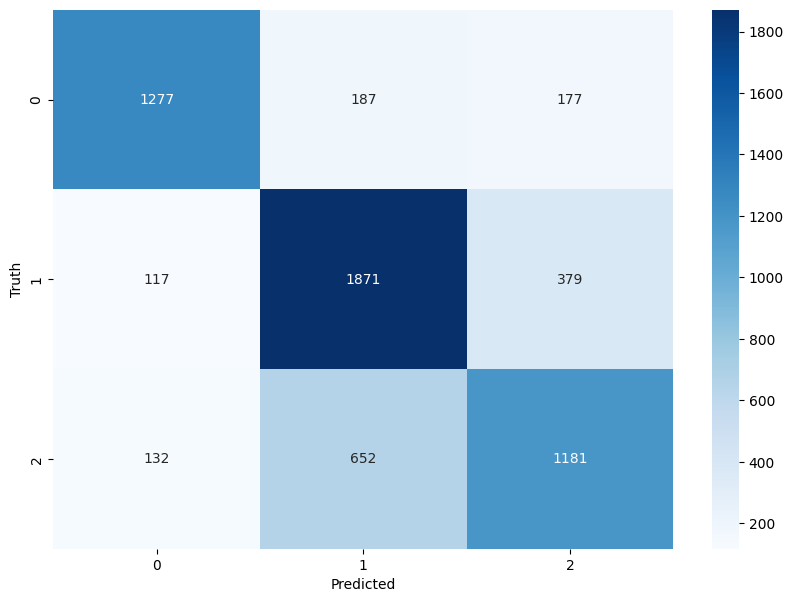

In [14]:
plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

Predict a sample

In [15]:
sample_input = X_test.iloc[[0]]
model.predict(sample_input)

array([0])

Tune parameters

**1. Number of trees**

In [16]:
model_50 = RandomForestClassifier(n_estimators=50, random_state=42)
model_50.fit(X_train, y_train)
model_50.score(X_test, y_test)

0.7311233885819521

In [17]:
model_100 = RandomForestClassifier(n_estimators=100, random_state=42)
model_100.fit(X_train, y_train)
model_100.score(X_test, y_test)

0.7373179306880965

Best score check

In [18]:
best_model = model_100
best_model.score(X_test, y_test)

0.7373179306880965

In [20]:
import joblib

joblib.dump(model, 'random_forest_model.joblib')
loaded_model = joblib.load('random_forest_model.joblib')